# Section 1 - Import Libraries

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

- Why these libraries?
  - Library	           || Purpose
  - Pandas             ||	Data handling
  - NumPy	             || Numerical operations
  - train_test_split   ||	Train/test division
  - ColumnTransformer	 || Different preprocessing for different columns
  - Pipeline	         || Combine preprocessing + model
  - OneHotEncoder	     || Encode categorical variables
  SimpleImputer	       || Handle missing values safely
  RandomForestRegressor	|| Regression model
  MAE	                 || Prediction error
  RMSE	               || Prediction error
  R²	                 || Model performance
  Joblib	             || Save trained pipeline

# Section 2 - Load Cleaned Dataset

In [2]:
df = pd.read_csv("cleaned_cars.csv")

In [ ]:
df.head()
df.shape
df.info()

# Section 3 - Define Features and Target

In [3]:
X = df.drop(columns=["selling_price", "car_name", "model"])

y = df["selling_price"]

In [4]:
print("X shape:", X.shape)
print("y shape:", y.shape)

# Observation:
  # X = Information about the car
  # y = Price we want to predict

X shape: (15409, 10)
y shape: (15409,)


# Section 4 - Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Approximately :
  # 80% → Training
  # 20% → Testing

Training data: (12327, 10)
Testing data: (3082, 10)


# Section 5 - Identify Column Types

In [7]:
# Numerical
numerical_columns = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

In [8]:
# Categorical
categorical_columns = [
    "brand",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

In [9]:
print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Categorical columns:
['brand', 'seller_type', 'fuel_type', 'transmission_type']


# Section 6 - Create Numerical Preprocessor

In [11]:
# Even though our cleaned dataset currently doesn't have missing values, we're going to build a robust pipeline.
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Observations:
# Why median?
  # If a numerical value is missing:

    # Mileage
    # 45000
    # 52000
    # NaN
    # 61000

# The pipeline can replace NaN with the median.
# This makes our application safer when we eventually receive new data.

# Section 7 - Create Categorical Preprocessor

In [12]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Observations:
# handle_unknown="ignore" -> This will be very important for Streamlit.
# Suppose our training data contains: Toyota, Hyundai, Maruti, Honda
# Later a user enters: Tesla
# The model shouldn't crash just because it has never seen Tesla during training.
# handle_unknown="ignore" helps prevent that problem.



# Section 8 - Combine the Preprocessors

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

# Now our preprocessing looks like:

#                     Input Data
#                         │
#              ┌──────────┴──────────┐
#              │                     │
#         Numerical              Categorical
#              │                     │
#           Imputer              Imputer
#              │                     │
#              │                OneHotEncoder
#              │                     │
#              └──────────┬──────────┘
#                         │
#                    Preprocessor

# Section 9 - Create ML Model

In [15]:
# We'll start with: Random Forest Regression

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# n_estimators=200 -> means the Random Forest will build 200 decision trees.
# n_jobs=-1        -> tells sklearn to use available CPU cores.

# Section 10 - Create the Complete Pipeline

In [16]:
# This is the most important section of the notebook.

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# Now we have:

# Raw Data
#    ↓
# Preprocessor
#    ├── Numerical → Imputation
#    │
#    └── Categorical → Imputation → One-Hot Encoding
#    ↓
# Random Forest
#    ↓
# Prediction

# This is what we eventually save.

# Section 11 - Train the Model

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['vehicle_age', 'km_driven',
                                                   'mileage', 'engine',
                                                   'max_power', 'seats']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['brand', 'seller_type',
                                                   'fuel_type',
                                                   'transmission_type'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

# Section - 12 Make Predictions

In [18]:
y_pred = pipeline.predict(X_test)


In [19]:
# Check a few predictions
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,298000,4.067100e+05
1,3100000,2.817768e+06
2,375000,4.394950e+05
3,320000,3.744876e+05
4,435000,4.400600e+05
5,450000,4.949760e+05
6,470000,4.697071e+05
7,1085000,1.051770e+06
8,700000,7.076625e+05
9,200000,2.527250e+05


# Section 13 - Evaluate the Model

In [23]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.2f}")

# Observations:
  # 1 → Excellent fit
  # 0 → Model explains little variance
  # < 0 → Very poor model

MAE: 94911.8287
RMSE: 184314.5789
R² Score: 0.94


# Section - 14 Actual vs Predicted

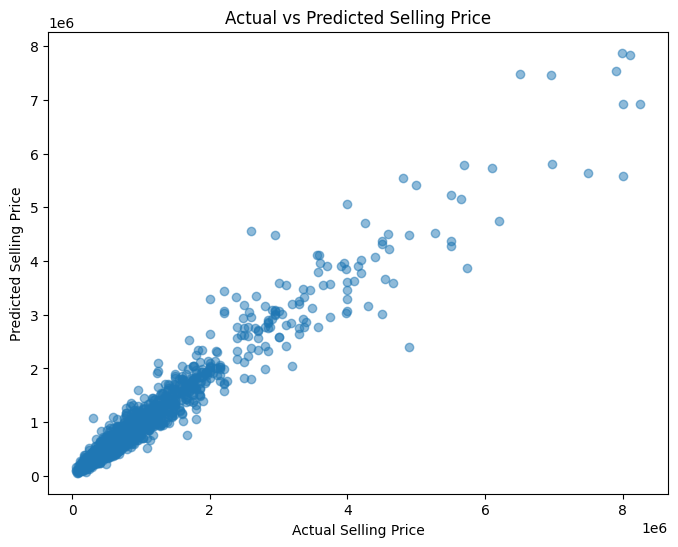

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()
# Ideally, points are roughly follow a diagonal pattern.

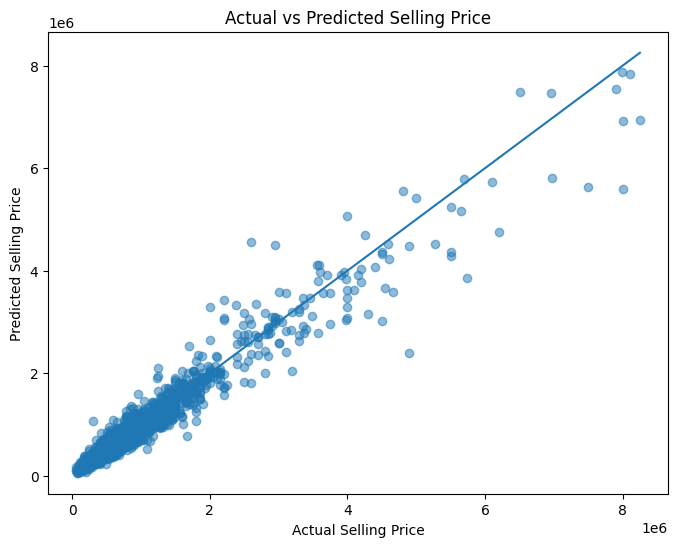

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

# Section 15 - Save the Pipeline

In [28]:
# This is the bridge between Data Science and Streamlit.

joblib.dump(
    pipeline,
    "car_price_pipeline.pkl"
)

['car_price_pipeline.pkl']

In [29]:
# Check
import os

print(os.path.exists("car_price_pipeline.pkl"))

True
